In [3]:
!pip install imblearn

In [23]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
file_path = 'processed_data.csv'
data = pd.read_csv(file_path)

#Split 70/15/15

# Undersample

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Define features (X) and target (y)
X = data.drop(['Flight_Status_Binary', 'Flight_Status', 'FL_DATE',
               'CRS_DEP_TIME', 'OP_UNIQUE_CARRIER', 'DEST', 'DEST_REGION'], axis=1)
y = data['Flight_Status_Binary']

# Step 1: Split into training (70%) and temp dataset (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Step 2: Further split temp into validation (15%) and testing (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Step 3: Perform undersampling on the training dataset only
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Verify the shape and class distributions
print("Dataset Shapes:")
print(f"Original Training Set: {X_train.shape}")
print(f"Resampled Training Set: {X_train_resampled.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Testing Set: {X_test.shape}")

print("\nTraining Set Class Distribution (Original):")
print(y_train.value_counts())

print("\nTraining Set Class Distribution (After Resampling):")
print(y_train_resampled.value_counts())

Dataset Shapes:
Original Training Set: (129920, 25)
Resampled Training Set: (27704, 25)
Validation Set: (27840, 25)
Testing Set: (27840, 25)

Training Set Class Distribution (Original):
Flight_Status_Binary
0    116068
1     13852
Name: count, dtype: int64

Training Set Class Distribution (After Resampling):
Flight_Status_Binary
0    13852
1    13852
Name: count, dtype: int64


## Modeling Building

Logistic Model

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train model on resampled training data
model.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation data
y_pred_val = model.predict(X_val)

# Performance evaluation
print(classification_report(y_val, y_pred_val))
print(confusion_matrix(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.92      0.56      0.70     24871
           1       0.14      0.59      0.23      2969

    accuracy                           0.57     27840
   macro avg       0.53      0.58      0.46     27840
weighted avg       0.84      0.57      0.65     27840

[[14050 10821]
 [ 1203  1766]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_val_pred_rf = rf.predict(X_val)
print("Random Forest Validation Report:")
print(classification_report(y_val, y_val_pred_rf))

Random Forest Validation Report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76     24871
           1       0.18      0.66      0.28      2969

    accuracy                           0.65     27840
   macro avg       0.56      0.65      0.52     27840
weighted avg       0.86      0.65      0.71     27840



##Xgboost

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)

y_val_pred_xgb = xgb.predict(X_val)
print("XGBoost Validation Report:")
print(classification_report(y_val, y_val_pred_xgb))

XGBoost Validation Report:
              precision    recall  f1-score   support

           0       0.95      0.66      0.78     24871
           1       0.19      0.69      0.30      2969

    accuracy                           0.66     27840
   macro avg       0.57      0.67      0.54     27840
weighted avg       0.87      0.66      0.73     27840



##Since our goal number 2 is to reduce delay times by informing logistics, its better to catch more delays. Using a lower threshold to increase recall, since missing a delay would be worse than predicting one that doesn't end up happening

##Find which is the best threshold with AUC

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Train a simple random forest model on data
best_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [15]:
# Predict probabilities for the positive class (delays/cancellations)
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

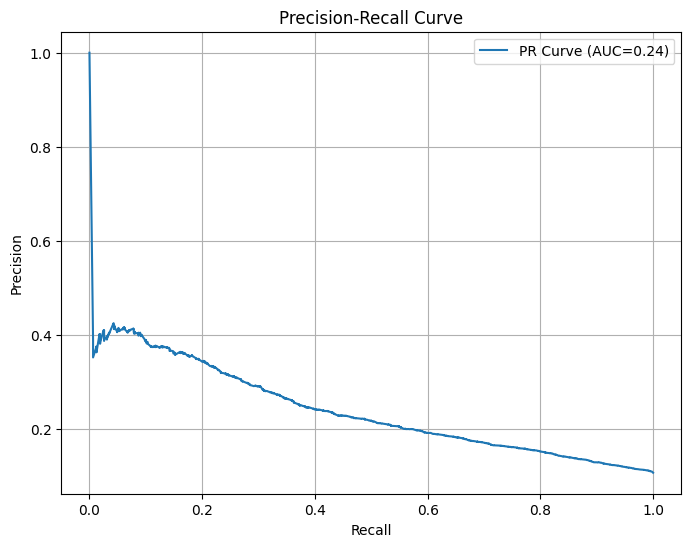

In [16]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PR Curve (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.51, 0.05)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    results.append([threshold, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1-score'])
print(results_df)

   Threshold  Precision    Recall  F1-score
0       0.10   0.111495  0.990229  0.200423
1       0.15   0.114386  0.969003  0.204617
2       0.20   0.118907  0.950135  0.211363
3       0.25   0.124584  0.920148  0.219454
4       0.30   0.133171  0.884771  0.231498
5       0.35   0.142210  0.835916  0.243068
6       0.40   0.154194  0.792790  0.258174
7       0.45   0.164611  0.719340  0.267913
8       0.50   0.181361  0.655660  0.284129


In [19]:
final_threshold = 0.25
y_pred_final = (y_proba_rf >= final_threshold).astype(int)

print("Final Threshold (0.25) Classification Report:")
print(classification_report(y_test, y_pred_final))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Threshold (0.25) Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.22      0.36     24872
           1       0.12      0.92      0.22      2968

    accuracy                           0.30     27840
   macro avg       0.54      0.57      0.29     27840
weighted avg       0.87      0.30      0.35     27840

Confusion Matrix:
[[ 5511 19361]
 [  226  2742]]


random Forest with 0.25

In [20]:
# Predict probabilities
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Set optimal threshold
threshold = 0.25
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# Evaluation metrics
print("Random Forest with threshold = 0.25")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest with threshold = 0.25
              precision    recall  f1-score   support

           0       0.96      0.22      0.36     24872
           1       0.12      0.92      0.22      2968

    accuracy                           0.30     27840
   macro avg       0.54      0.57      0.29     27840
weighted avg       0.87      0.30      0.35     27840

[[ 5511 19361]
 [  226  2742]]


Logistic with 0.25

In [25]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on resampled training data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predict probabilities
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Apply optimal threshold
y_pred_lr = (y_proba_lr >= threshold).astype(int)

# Evaluation metrics
print("Logistic Regression with threshold = 0.25")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression with threshold = 0.25
              precision    recall  f1-score   support

           0       0.97      0.01      0.02     24872
           1       0.11      1.00      0.19      2968

    accuracy                           0.11     27840
   macro avg       0.54      0.50      0.11     27840
weighted avg       0.88      0.11      0.04     27840

[[  233 24639]
 [    6  2962]]


XGBoost with 0.25 threshold

In [26]:
from xgboost import XGBClassifier

# Train XGBoost model on resampled training data
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Apply optimal threshold
y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

# Evaluation metrics
print("XGBoost with threshold = 0.25")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost with threshold = 0.25
              precision    recall  f1-score   support

           0       0.97      0.23      0.37     24872
           1       0.13      0.95      0.23      2968

    accuracy                           0.31     27840
   macro avg       0.55      0.59      0.30     27840
weighted avg       0.88      0.31      0.36     27840

[[ 5739 19133]
 [  158  2810]]


##Best model

Recall (95%): Almost as good as Logistic Regression, significantly fewer false positives.

Precision (13%): Slightly higher precision than both Random Forest and Logistic Regression, fewer false alarms.

Balanced Performance: XGBoost offers a better overall balance of high recall and relatively better precision compared to the other two models.

Overall this will ensure that we catch all critical delays whitout overwhelming the team with too many false alarms. This aligns with our goal number 2